# Exploratory Data Analysis: Speed Dating Dataset

**Objective:**
To perform a comprehensive Exploratory Data Analysis (EDA) on the Speed Dating dataset (OpenML ID: 40536) to understand its underlying structure, identify missing values, and uncover key patterns and correlations that influence a successful match.

**Project Structure Note:**
Following the `cookiecutter-data-science` template, raw data will be saved to `../data/raw/` and processed data to `../data/processed/`.

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.datasets import fetch_openml
import warnings

warnings.filterwarnings('ignore')

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Data Acquisition
We will fetch the dataset directly from OpenML using its ID (40536). To comply with the `cookiecutter-data-science` structure, we will save the raw downloaded file into the `../data/raw/` directory.

In [2]:
# Define paths based on cookiecutter structure
RAW_DATA_DIR = '../data/raw/'
RAW_DATA_PATH = os.path.join(RAW_DATA_DIR, 'speed_dating.csv')

# Create directory if it doesn't exist (useful if running outside the strict template)
os.makedirs(RAW_DATA_DIR, exist_ok=True)

# Fetch data from OpenML or load locally if already exists
if not os.path.exists(RAW_DATA_PATH):
    print("Fetching dataset from OpenML...")
    dataset = fetch_openml(data_id=40536, as_frame=True, parser='auto')
    df = dataset.frame
    # Save raw data to follow template standards
    df.to_csv(RAW_DATA_PATH, index=False)
    print(f"Data saved to {RAW_DATA_PATH}")
else:
    print(f"Loading data from {RAW_DATA_PATH}...")
    df = pd.read_csv(RAW_DATA_PATH)

print("Dataset successfully loaded!")

Fetching dataset from OpenML...
Data saved to ../data/raw/speed_dating.csv
Dataset successfully loaded!


## 2. Basic Data Overview
Let's understand the shape, columns, and initial rows of our dataset.

In [3]:
# Display dataset shape
print(f"The dataset contains {df.shape[0]} rows and {df.shape[1]} columns.")

# Display basic info
display(df.info())

# Show first 5 rows
display(df.head())

The dataset contains 8378 rows and 121 columns.
<class 'pandas.DataFrame'>
RangeIndex: 8378 entries, 0 to 8377
Columns: 121 entries, has_null to match
dtypes: category(62), float64(57), int64(2)
memory usage: 4.3 MB


None

,has_null,wave,gender,age,age_o,d_age,d_d_age,race,race_o,samerace,...,expected_num_matches,d_expected_happy_with_sd_people,d_expected_num_interested_in_me,d_expected_num_matches,like,guess_prob_liked,d_like,d_guess_prob_liked,met,match
0,0,1,female,21.0,27.0,6,[4-6],Asian/Pacific Islander/Asian-American,European/Caucasian-American,0,...,4.0,[0-4],[0-3],[3-5],7.0,6.0,[6-8],[5-6],0.0,0
1,0,1,female,21.0,22.0,1,[0-1],Asian/Pacific Islander/Asian-American,European/Caucasian-American,0,...,4.0,[0-4],[0-3],[3-5],7.0,5.0,[6-8],[5-6],1.0,0
2,1,1,female,21.0,22.0,1,[0-1],Asian/Pacific Islander/Asian-American,Asian/Pacific Islander/Asian-American,1,...,4.0,[0-4],[0-3],[3-5],7.0,NaN,[6-8],[0-4],1.0,1
3,0,1,female,21.0,23.0,2,[2-3],Asian/Pacific Islander/Asian-American,European/Caucasian-American,0,...,4.0,[0-4],[0-3],[3-5],7.0,6.0,[6-8],[5-6],0.0,1
4,0,1,female,21.0,24.0,3,[2-3],Asian/Pacific Islander/Asian-American,Latino/Hispanic American,0,...,4.0,[0-4],[0-3],[3-5],6.0,6.0,[6-8],[5-6],0.0,1


## 3. Data Cleaning & Missing Values
Real-world data is messy. The Speed Dating dataset is known to have a significant amount of missing values because participants didn't always fill out every part of their surveys.

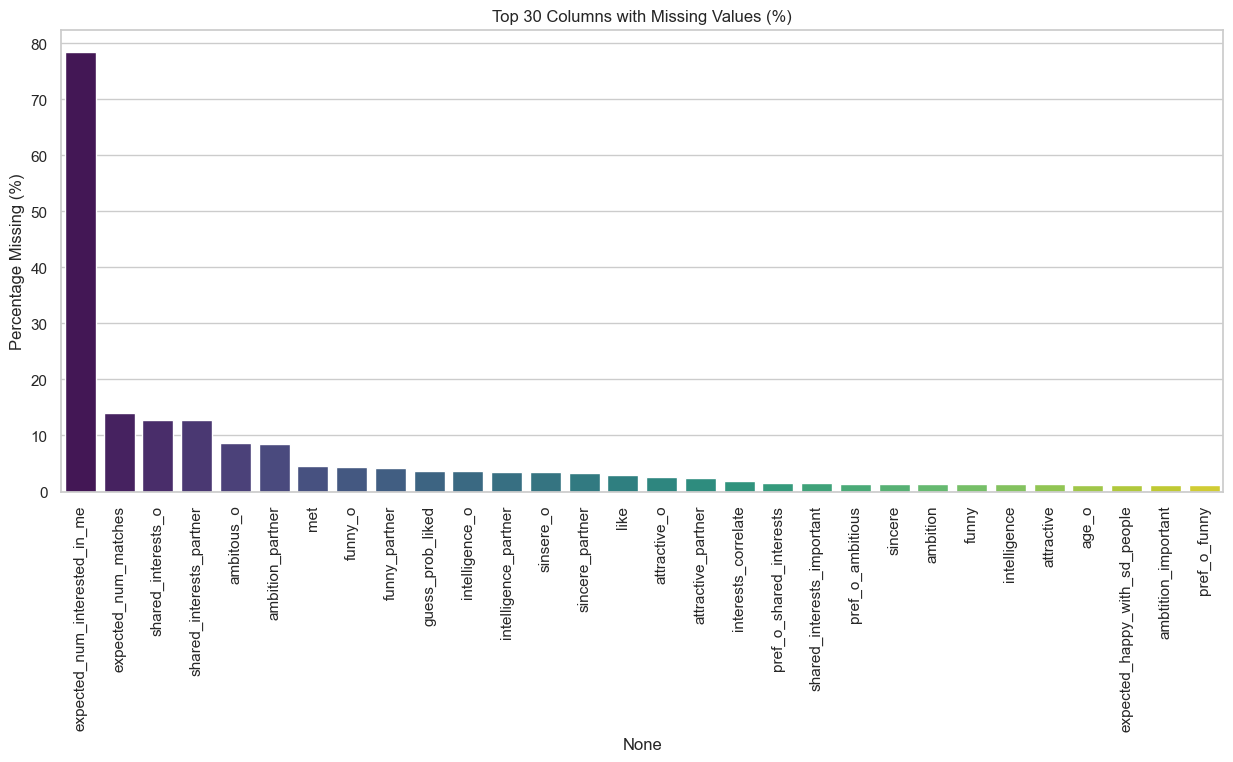

Top 5 missing columns:
 expected_num_interested_in_me    78.515159
expected_num_matches             14.000955
shared_interests_o               12.843161
shared_interests_partner         12.735736
ambitous_o                        8.617809
dtype: float64


In [4]:
# Calculate percentage of missing values for each column
missing_values = df.isnull().mean() * 100
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

# Plotting missing values
plt.figure(figsize=(15, 6))
sns.barplot(x=missing_values.index[:30], y=missing_values.values[:30], palette='viridis')
plt.xticks(rotation=90)
plt.title('Top 30 Columns with Missing Values (%)')
plt.ylabel('Percentage Missing (%)')
plt.show()

# Print top 5 columns with highest missing rates
print("Top 5 missing columns:\n", missing_values.head(5))

**Insight:** Some columns have a very high percentage of missing values (e.g., expected return parameters). We should consider dropping columns with >50% missing values during the modeling phase. For now, we will leave them for analysis.

## 4. Univariate Analysis
Let's analyze the distribution of individual variables, starting with the target variable (`match`), followed by `gender` and `age`.

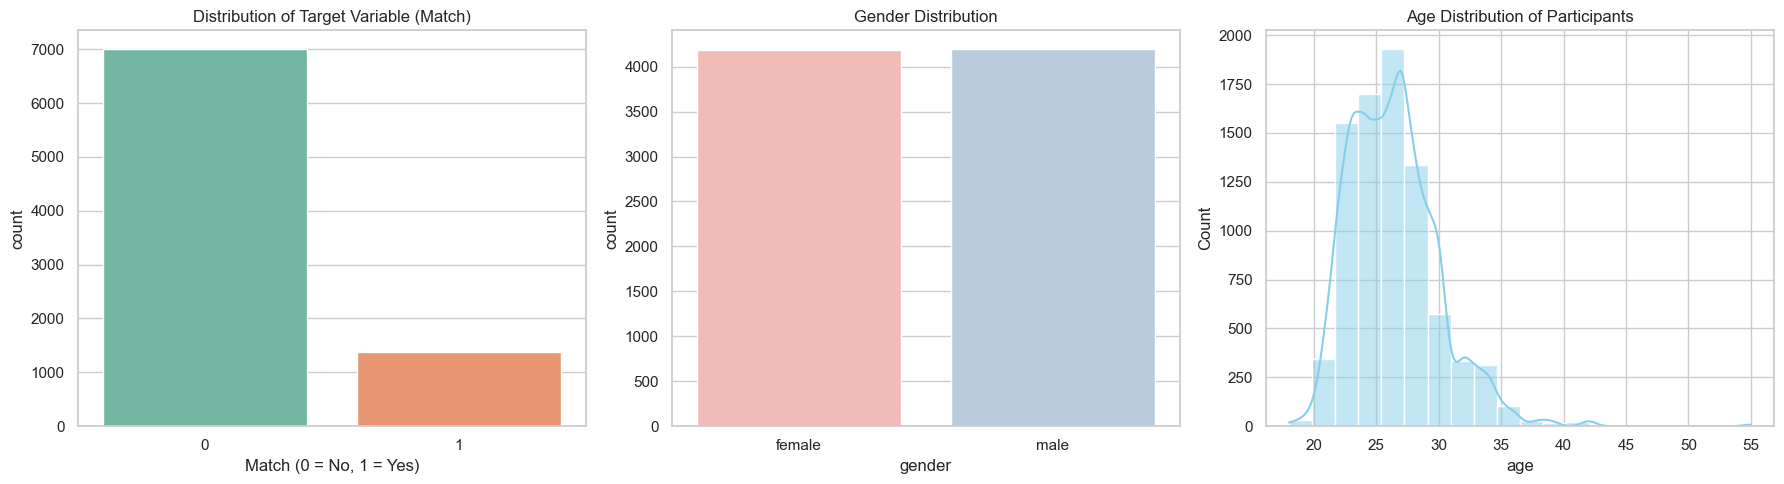

Overall Match Rate: 16.47%


In [5]:
# Target Variable Distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Match Distribution (Target Variable)
sns.countplot(data=df, x='match', ax=axes[0], palette='Set2')
axes[0].set_title('Distribution of Target Variable (Match)')
axes[0].set_xlabel('Match (0 = No, 1 = Yes)')

# 2. Gender Distribution
sns.countplot(data=df, x='gender', ax=axes[1], palette='Pastel1')
axes[1].set_title('Gender Distribution')

# 3. Age Distribution
# Convert 'age' to numeric in case it's loaded as category/object
df['age'] = pd.to_numeric(df['age'], errors='coerce')
sns.histplot(df['age'].dropna(), bins=20, kde=True, ax=axes[2], color='skyblue')
axes[2].set_title('Age Distribution of Participants')

plt.tight_layout()
plt.show()

match_rate = df['match'].astype(float).mean() * 100
print(f"Overall Match Rate: {match_rate:.2f}%")

**Insight:** - The dataset is imbalanced. Only about ~16.5% of speed dates result in a match.
- Gender representation is roughly equal.
- Most participants are in their mid-20s.

## 5. Bivariate Analysis
How do features relate to the target variable (`match`)? Are there differences between genders in terms of what they find important in a partner?

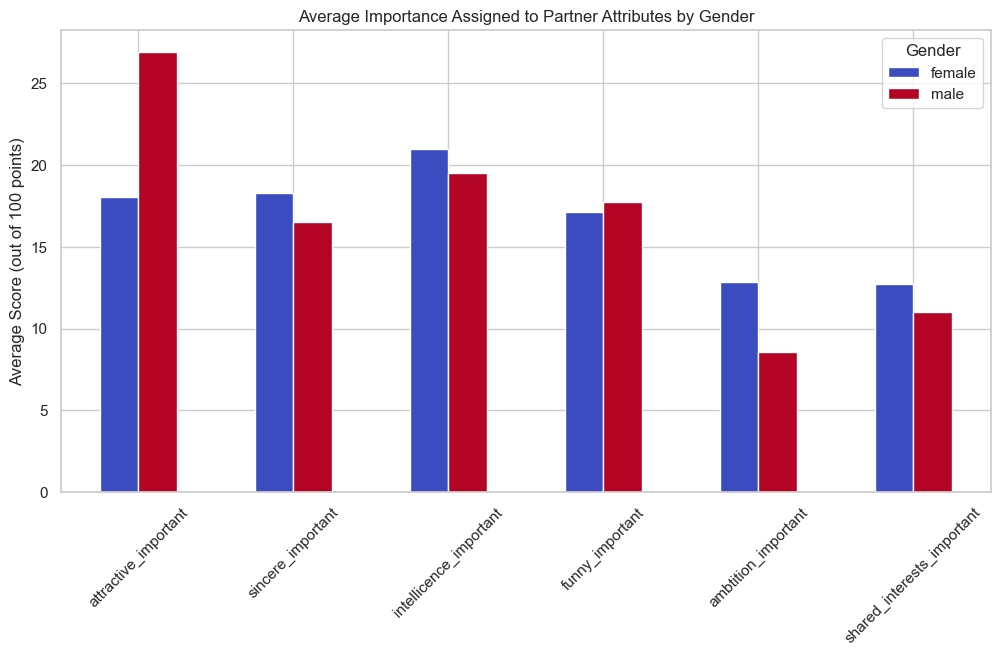

In [6]:
# Let's explore what attributes men vs women find important in a partner
# Attributes: attractive, sincere, intelligence, funny, ambition, shared_interests

importance_cols = [
    'attractive_important', 'sincere_important', 'intellicence_important', 
    'funny_important', 'ambtition_important', 'shared_interests_important'
]

# Convert columns to numeric to compute means safely
for col in importance_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

gender_importance = df.groupby('gender')[importance_cols].mean().T

# Plotting Radar/Bar chart equivalent for importance
gender_importance.plot(kind='bar', figsize=(12, 6), colormap='coolwarm')
plt.title('Average Importance Assigned to Partner Attributes by Gender')
plt.ylabel('Average Score (out of 100 points)')
plt.xticks(rotation=45)
plt.legend(title='Gender')
plt.show()

**Insight:** Males tend to place a higher importance on attractiveness (`attractive_important`), while females generally value ambition (`ambtition_important`) and intelligence slightly more.

## 6. Correlation Analysis
Let's analyze the relationships between continuous variables, especially the ratings given by participants to their partners during the date.

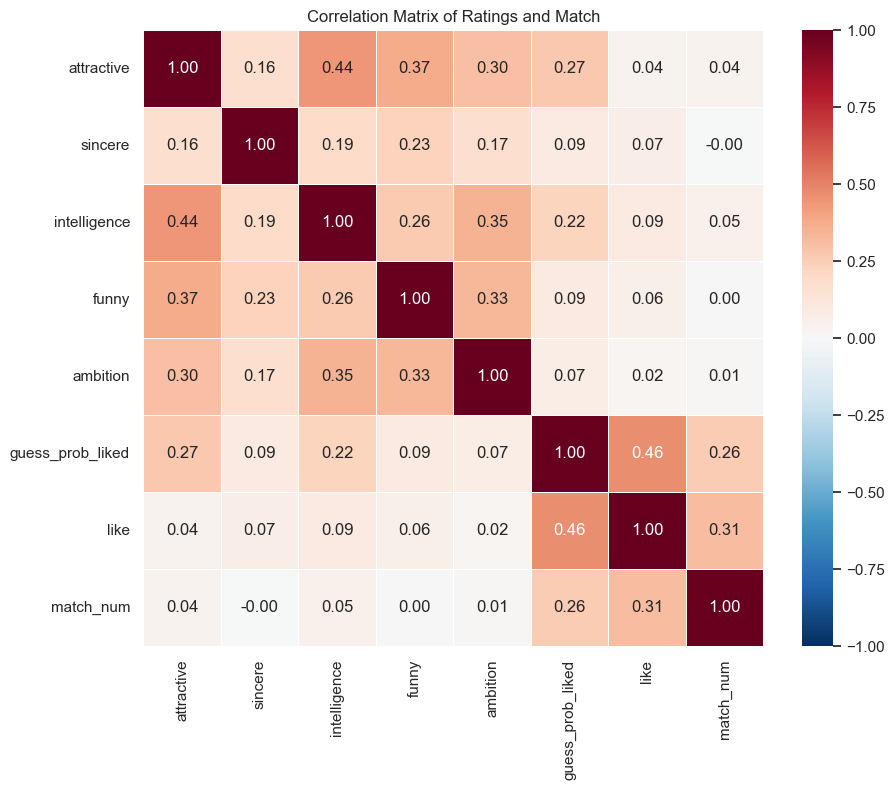

In [7]:
# Select ratings columns given to partners
rating_cols = ['attractive', 'sincere', 'intelligence', 'funny', 'ambition', 'guess_prob_liked', 'like', 'match']

# Convert target to numeric for correlation
df['match_num'] = pd.to_numeric(df['match'], errors='coerce')
rating_cols[-1] = 'match_num' # update target col name

for col in rating_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Calculate Correlation Matrix
corr_matrix = df[rating_cols].corr()

# Plot Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', vmin=-1, vmax=1, fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Ratings and Match')
plt.show()

**Insight:**
- The overall `like` score is highly correlated with how `attractive` and `funny` the partner was perceived.
- A successful `match` is positively correlated with the `like` score and the perceived `attractiveness`.
- Sincerity and Intelligence show weaker correlations with the actual decision to match.

## 7. Conclusions & Next Steps

**Key Findings:**
1. **Class Imbalance:** Matches are rare (approx 16%). This implies we may need techniques like SMOTE or class weighting during model training.
2. **Missing Data:** Several specific survey responses have >40% missing values. We need robust imputation strategies or to drop certain columns before creating the final processed dataset.
3. **Attribute Importance:** Gender plays a significant role in what is prioritized in a partner.
4. **Match Drivers:** Attractiveness and humor are the strongest numerical predictors of high 'like' scores.

**Next Steps for `data/processed/` pipeline:**
* Drop columns with >50% missing values.
* Impute missing continuous variables with median, and categorical variables with mode.
* Encode categorical variables (`gender`, `race`, etc.) using One-Hot Encoding.
* Save the cleaned dataframe to `../data/processed/speed_dating_cleaned.csv` for modeling.